Insurance Price Prediction - Basic

In [1]:
medical_charges_url = 'https://raw.githubusercontent.com/JovianML/opendatasets/master/data/medical-charges.csv'

from urllib.request import urlretrieve

In [2]:
urlretrieve(medical_charges_url, 'ml_linear_regression_medical.csv')

('ml_linear_regression_medical.csv', <http.client.HTTPMessage at 0x108ee6350>)

In [3]:
pip install pandas

  Using cached pandas-3.0.1-cp314-cp314-macosx_11_0_arm64.whl.metadata (79 kB)
  Using cached numpy-2.4.2-cp314-cp314-macosx_14_0_arm64.whl.metadata (6.6 kB)
Using cached pandas-3.0.1-cp314-cp314-macosx_11_0_arm64.whl (9.9 MB)
Using cached numpy-2.4.2-cp314-cp314-macosx_14_0_arm64.whl (5.2 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]━━━━ 1/2 [pandas]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd

df_medical = pd.read_csv("ml_linear_regression_medical.csv")
df_medical.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [2]:
df_medical.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [3]:
df_medical.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [4]:
## Inferences from the data - 
### 1. Insurance is provided from the age 18-64
### 2. 75 percent of people have BMI < 34.7, with average being 30.6. The rest are serious outliers on both ends of the spectrum
### 3. Mean number of children is 1.09, and 75% of people have less than 2 kids. 25% of people don't have kids. Number of single child applications are dominating the data, with 25% of data being between 2 and 5
### 4. Huge skewness in charges (Min - 1100 and max - 64k)

Exploratory Data Analysis

In [ ]:
# # pip install matplotlib plotly seaborn --quiet

# pip install nbformat ipython --quiet


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [6]:
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

In [7]:
# EDA for Age

df_medical['age'].describe()

count    1338.000000
mean       39.207025
std        14.049960
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64

In [10]:
fig = px.histogram(df_medical, x='age', marginal='box', nbins=47, title='Age Dist')
fig.update_layout(bargap=0.1)
fig.show()

# Interpretation of chart - 
# 1. Almost uniform distribution, with 20-30 customers at every range
# 2. If correlated with overall distribution of age in US (tot population), there are not many variations, which supports our sampling (This insurance company is representative of the overall population of the United States)
# 3. Ages 18-19 are outliers, with slight upward trend between ages 40 and 50
# 
# Why the increase for ages 18 and 19? Probably because lower premiums if you sign up before 20 

In [11]:
# EDA for BMI

df_medical['bmi'].describe()

count    1338.000000
mean       30.663397
std         6.098187
min        15.960000
25%        26.296250
50%        30.400000
75%        34.693750
max        53.130000
Name: bmi, dtype: float64

In [12]:
fig = px.histogram(df_medical, x='bmi', marginal='box', color_discrete_sequence=['blue'], title='BMI Dist')
fig.update_layout(bargap=0.1)
fig.show()

# Interpretation - 
## 1. Gaussian distribution

In [13]:
# EDA - Charges

df_medical['charges'].describe()

count     1338.000000
mean     13270.422265
std      12110.011237
min       1121.873900
25%       4740.287150
50%       9382.033000
75%      16639.912515
max      63770.428010
Name: charges, dtype: float64

In [14]:
fig = px.histogram(df_medical, x='charges', marginal='box', color='smoker', color_discrete_sequence=['green','grey'], title='Medical Charges')
fig.update_layout(bargap=0.1)
fig.show()

# Interpretation
# 1. Trend - Smokers pay more premiums
# 2. Most people fall under 2k - 15k
# 3. This distribution is called Power Law - Most are concentrated at the start but exponentially drop off
# 4. Non smokers - Exponentially trail off but for smokers - there are 2 hills, meaning there is another factor at play here - maybe ailments combined with smoking or light/heavy smokers?
# 5. Median charges for non smokers - 7.3k but for smokers - 35k??? 

In [15]:
# EDA for smokers

df_medical['smoker'].describe()

count     1338
unique       2
top         no
freq      1064
Name: smoker, dtype: object

In [16]:
px.histogram(df_medical, x='smoker', color='sex', title='Smoker')

In [17]:
# Age and Charges

px.scatter(df_medical, x='age', y='charges', opacity=0.8, color='smoker',title='Age vs Charges')

# Observations - 

# 1. Medical charges increase with age, but that's not the only factor; roughly a linear trend
# 2. Three clear clusers - Major one is healthy non-smokers; 2nd is a mix of smokers and non smokers - distinct but overlapping; last cluster is exclusively smokers

In [18]:
# BMI and Charges

px.scatter(df_medical, x='bmi', y='charges', opacity=0.8, color='smoker',title='BMI vs Charges')

# Observations - 

# 1. No clear trend for non-smokers
# 2. 2 clear clusters for smokers

In [19]:
# Children and Charges

px.violin(df_medical, x='children', y='charges', title='Children vs Charges')

# Observations - 

# 1. No clear trend for non-smokers
# 2. 2 clear clusters for smokers

Correlation

In [20]:
print(df_medical['charges'].corr(df_medical['children']))
print(df_medical['charges'].corr(df_medical['age']))
print(df_medical['charges'].corr(df_medical['bmi']))

0.0679982268479048
0.29900819333064754
0.19834096883362884


In [21]:
# For categorical columns

smoker_values = {'no':0, 'yes':1}
smoker_numeric = df_medical['smoker'].map(smoker_values)
df_medical['charges'].corr(smoker_numeric)

## Correlation

# Denotes strength of relationship between 2 variables
# -1/1 => Perfectly linear relationship, where a change in one variable is accompanied by a perfect consistent change in the other; this is not realistic in real life
# 0 => No linear relationship, as one value increases, there's no tendency for the other value to increase / decrease
# [-1,0] and [0, 1] => There is a relationship, but not all points fall on the line

# Positive coefficient - When one value increases, the other increases too
# Negative coefficient - When one value decreases, the other decreases as well



np.float64(0.7872514304984772)

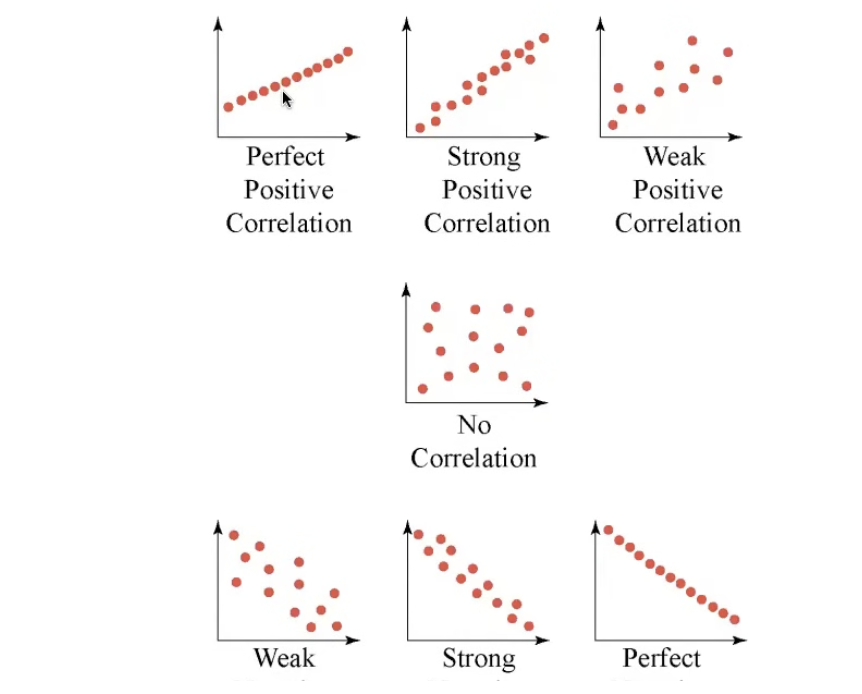

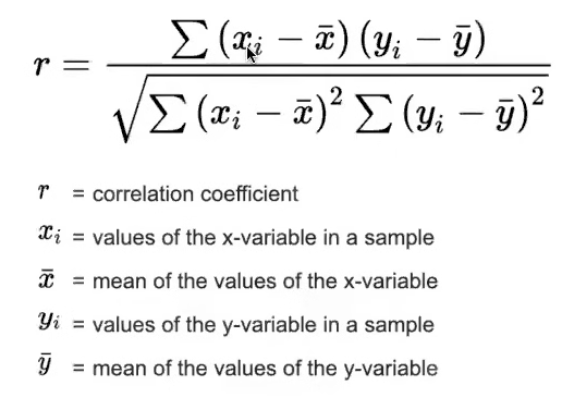

In [22]:
df_medical[["age","bmi","children","charges"]].corr()

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


In [23]:
## Correlation vs Causation

Linear Regression with a single feature

In [24]:
non_smoker_df = df_medical[df_medical['smoker']=='no']

<Axes: title={'center': 'Age vs Charges'}, xlabel='age', ylabel='charges'>

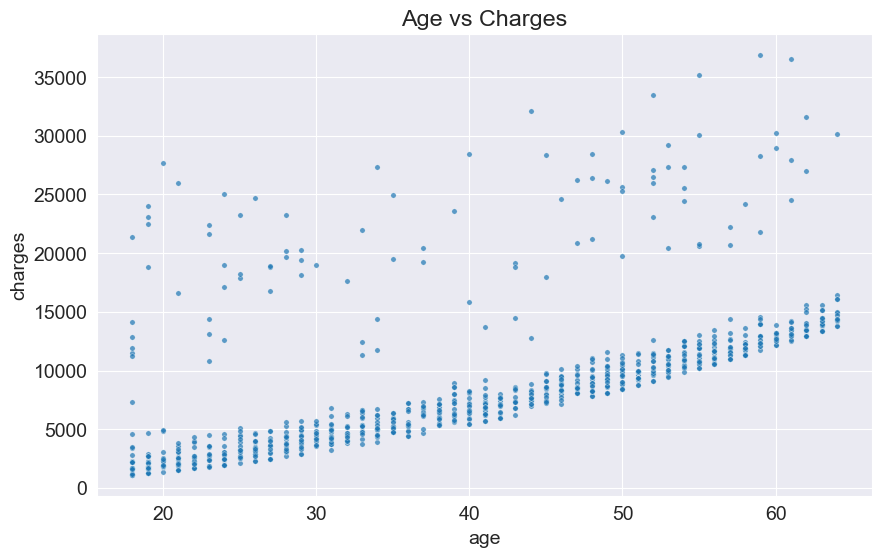

In [25]:
plt.title('Age vs Charges')
sns.scatterplot(data=non_smoker_df, x='age', y='charges', alpha=0.7, s=15)

y = wx + b

w -> Slope

b -> Intercept

In the above charges - 

y = w x age + b 

(This is called linear regression model)

In [26]:
def estimate_charges(age, w, b):
    return w*age + b

In [27]:
w = 50
b = 400
base_charges = estimate_charges(non_smoker_df['age'], w, b)
base_charges

1       1300
2       1800
3       2050
4       2000
5       1950
        ... 
1332    3000
1333    2900
1334    1300
1335    1300
1336    1450
Name: age, Length: 1064, dtype: int64

In [28]:
non_smoker_df['charges']
ages = non_smoker_df['age']

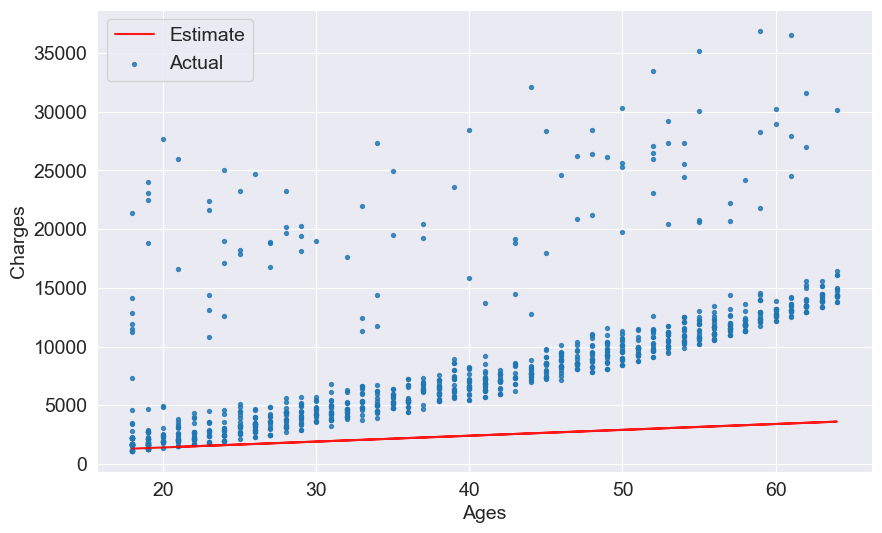

In [29]:
target = non_smoker_df['charges']
plt.plot(ages, base_charges, 'r', alpha=0.9)
plt.scatter(ages, target, s=8, alpha=0.8)
plt.xlabel('Ages')
plt.ylabel('Charges')
plt.legend(['Estimate', 'Actual'])

In [30]:
def try_charges(w , b):
    age = non_smoker_df['age']
    target = non_smoker_df['charges']
    estimated_charges = estimate_charges(age, w, b)
    plt.plot(ages, estimated_charges, 'r', alpha=0.9)
    plt.scatter(ages, target, s=8, alpha=0.8)
    plt.xlabel('Ages')
    plt.ylabel('Charges')
    plt.legend(['Estimate', 'Actual'])

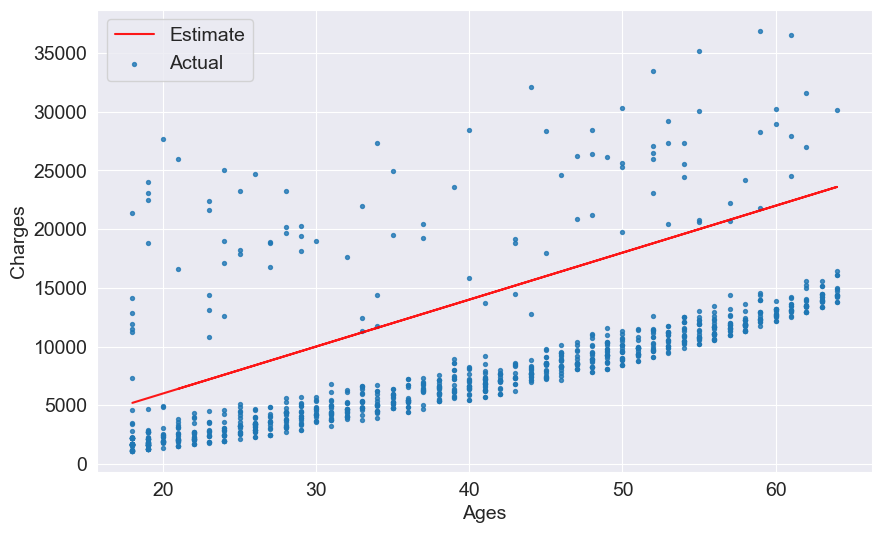

In [31]:
try_charges(400, -2000)

When -

w changes -> The incline changes

b changes -> The placement of the line (up/middle/down) changes (also called the 'y' intercept)

2 things that need to be figured here -
    1. How can I evaluate if the fit is right or not
    2. Based on this evaluation, how can I modify w and b to find the most optimal fit

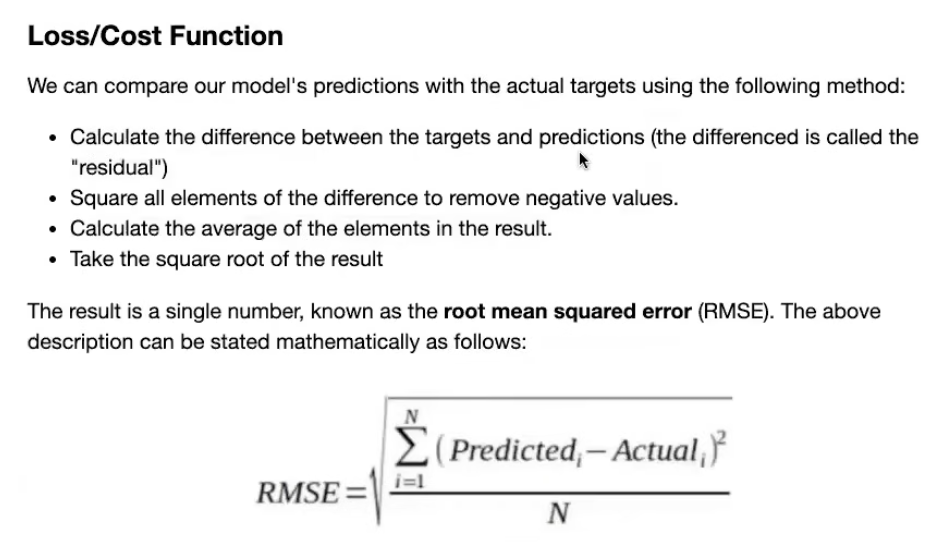

RMSE - Squared of the difference
Root Mean Absolute Error - No squares, just takes the absolute values

Why RMSE works best - If the outliers (difference between predicted and actual) are large, then the error becomes large

##### Loss / Cost Function

In [32]:
import numpy as np

def rmse(target, prediction):
    return np.sqrt(np.mean(np.square(prediction - target)))

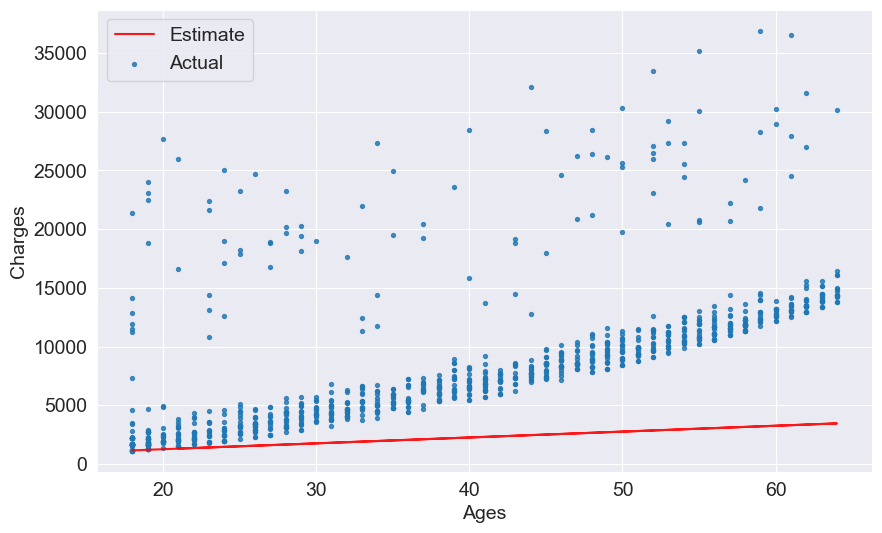

In [33]:
try_charges(50, 250)

In [34]:
target = non_smoker_df['charges']
predicted = estimate_charges(non_smoker_df['age'], w, b)

rmse(target, predicted)

# 8238.66 is called loss because it's the information loss produced by the model, if the range of values are between 2k and 15k (for non smokers, largely), then predictions on average being off by 8.2k is really bad. Lower the loss, better the model

np.float64(8238.664307473256)

In [35]:
def try_parameters(w , b):
    age = non_smoker_df['age']
    target = non_smoker_df['charges']
    estimated_charges = estimate_charges(age, w, b)
    plt.plot(ages, estimated_charges, 'r', alpha=0.9)
    plt.scatter(ages, target, s=8, alpha=0.8)
    plt.xlabel('Ages')
    plt.ylabel('Charges')
    plt.legend(['Estimate', 'Actual'])
    rmse_val = rmse(target, estimated_charges)
    print(f"RMSE: {rmse_val}")

RMSE: 4696.913193906309


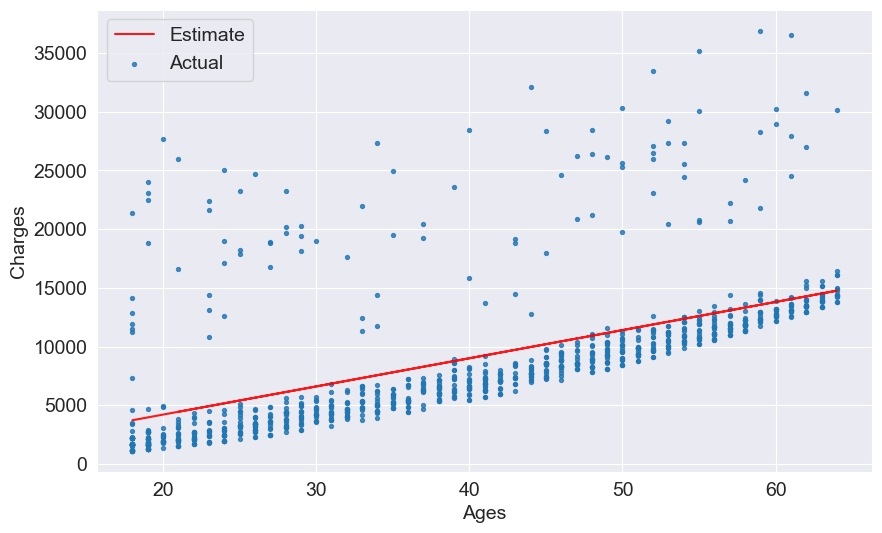

In [36]:
try_parameters(240, -600)

We need to find a statistical technique that modifies w and b such that the RMSE is lowest. There are a bunch of strategies, but 2 most important are Ordinary Least Squares (which works well in smaller datasets but fails at larger ones), and Stochastic Gradient Descent (which works well in larger datasets, uses calculus and matrix operations to make this happen)

In [116]:
pip install scikit-learn --quiet


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [37]:
from sklearn.linear_model import LinearRegression

In [38]:
model = LinearRegression() # Uses Ordinary Least Squares
help(model.fit)

Help on method fit in module sklearn.linear_model._base:

fit(X, y, sample_weight=None) method of sklearn.linear_model._base.LinearRegression instance
    Fit linear model.

    Parameters
    ----------
    X : {array-like, sparse matrix} of shape (n_samples, n_features)
        Training data.

    y : array-like of shape (n_samples,) or (n_samples, n_targets)
        Target values. Will be cast to X's dtype if necessary.

    sample_weight : array-like of shape (n_samples,), default=None
        Individual weights for each sample.

        .. versionadded:: 0.17
           parameter *sample_weight* support to LinearRegression.

    Returns
    -------
    self : object
        Fitted Estimator.



In [39]:
inputs = non_smoker_df[['age']]
target = non_smoker_df['charges']
print(inputs.shape)
print(target.shape)

(1064, 1)
(1064,)


In [40]:
model.fit(inputs, target)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [41]:
model.predict(np.array([[23],[39],[57]]))

/Users/capbanks/Projects/interview-prep/data-science-practice/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([ 4055.30443855,  8331.28704385, 13141.76747481])

In [44]:
predictions = model.predict(inputs)
predictions

array([2719.0598744 , 5391.54900271, 6727.79356686, ..., 2719.0598744 ,
       2719.0598744 , 3520.80661289], shape=(1064,))

In [45]:
target

1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
5        3756.62160
           ...     
1332    11411.68500
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
Name: charges, Length: 1064, dtype: float64

In [46]:
rmse(target, predictions)

np.float64(4662.505766636395)

In [47]:
model.coef_, model.intercept_

(array([267.24891283]), np.float64(-2091.4205565650773))

RMSE: 4662.505766636395


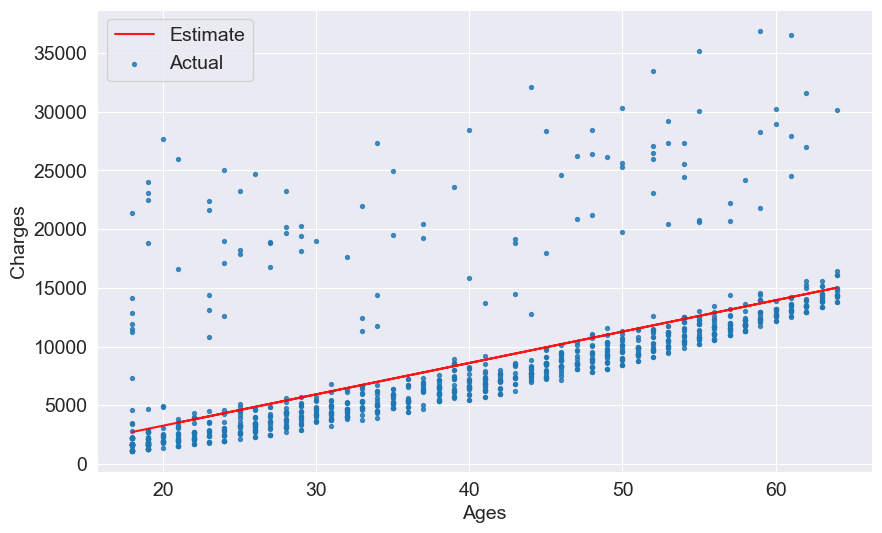

In [48]:
try_parameters(model.coef_, model.intercept_)

In [49]:
from sklearn.linear_model import SGDRegressor

In [50]:
model = SGDRegressor()

In [51]:
model.fit(inputs, target)

,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide `.",'squared_error'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None


In [52]:
predictions = model.predict(inputs)

In [53]:
rmse(target, predictions)

np.float64(4879.313690131669)

RMSE: 4879.313690131669


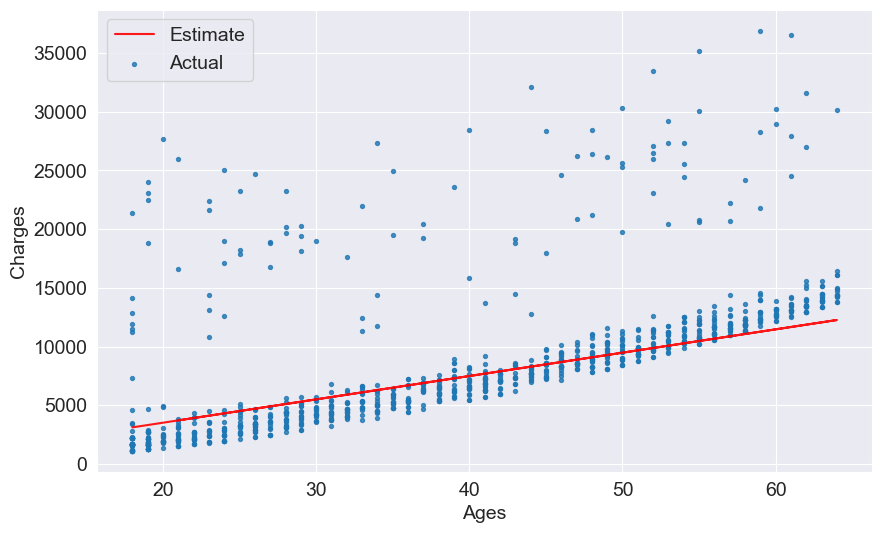

In [54]:
try_parameters(model.coef_, model.intercept_)

In [55]:
df_smokers = df_medical[df_medical['smoker']=='yes']
df_smokers

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
11,62,female,26.290,0,yes,southeast,27808.72510
14,27,male,42.130,0,yes,southeast,39611.75770
19,30,male,35.300,0,yes,southwest,36837.46700
23,34,female,31.920,1,yes,northeast,37701.87680
...,...,...,...,...,...,...,...
1313,19,female,34.700,2,yes,southwest,36397.57600
1314,30,female,23.655,3,yes,northwest,18765.87545
1321,62,male,26.695,0,yes,northeast,28101.33305
1323,42,female,40.370,2,yes,southeast,43896.37630


In [56]:
inputs = df_smokers[['age']]
targets = df_smokers['charges']
print(inputs.shape, targets.shape)

(274, 1) (274,)


In [57]:
model.fit(inputs, targets)

,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide `.",'squared_error'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None


In [58]:
predictions = model.predict(inputs)
rmse(targets, predictions)

np.float64(4836597864.048378)

In [59]:
df_medical

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [68]:
df_medical['smoker_code'] = df_medical['smoker'].map(smoker_values)
sex_code = {'male':1, 'female':0}
df_medical['sex_code'] = df_medical['sex'].map(sex_code)


In [62]:
# One-Hot Encoding
## For a column with small number of unique categories, we use One-Hot Encoding, where each unique value has a separate column to it, takes a value 1 if it's applicable, 0 otherwise

In [66]:
from sklearn import preprocessing

enc = preprocessing.OneHotEncoder()
enc.fit(df_medical[['region']])
enc.categories_
one_hot = enc.transform(df_medical[['region']]).toarray()
df_medical[['northeast', 'northwest', 'southeast', 'southwest']] = one_hot

In [70]:
input_cols = ['age','bmi','children','smoker_code','sex_code','northeast', 'northwest', 'southeast', 'southwest']
inputs, targets = df_medical[input_cols], df_medical['charges']

model = LinearRegression().fit(inputs, targets)
predictions = model.predict(inputs)

loss = rmse(targets, predictions)
print("Loss:",loss)

Loss: 6041.6796511744515


In [71]:
model.coef_

array([  256.85635254,   339.19345361,   475.50054515, 23848.53454191,
        -131.3143594 ,   587.00923503,   234.0453356 ,  -448.01281436,
        -373.04175627])

In [72]:
df_medical[input_cols].loc[10]

age            25.00
bmi            26.22
children        0.00
smoker_code     0.00
sex_code        1.00
northeast       1.00
northwest       0.00
southeast       0.00
southwest       0.00
Name: 10, dtype: float64

In [74]:
model.predict([[28, 30, 1, 1, 0, 1, 0, 0, 0]])

/Users/capbanks/Projects/interview-prep/data-science-practice/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([29753.27799027])

In [ ]:
model.coef_

# Observations - 
# ['age','bmi','children','smoker_code','sex_code','northeast', 'northwest', 'southeast', 'southwest'] - Column-Feature order
# 1. BMI has a higher weight than age, so does children - Directly conflicts our correlation observations - age has more influence. Why?
# Ans. The range of values in each column are not STANDARDIZED, which is highly important. When one column has a higher range of values as compared to another column with a lower range of values, the higher range plays a more significant role while optimizing cost function compared to the lower range

array([  256.85635254,   339.19345361,   475.50054515, 23848.53454191,
        -131.3143594 ,   587.00923503,   234.0453356 ,  -448.01281436,
        -373.04175627])

In [77]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ['age','bmi','children']
scaler = StandardScaler()
scaler.fit(df_medical[numeric_cols])

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [ ]:
scaler.mean_ # The mean

array([39.20702541, 30.66339686,  1.09491779])

In [80]:
scaler.var_ # The variance (square of standard deviation)

array([197.25385199,  37.16008997,   1.45212664])

In [82]:
scaled_inputs = scaler.transform(df_medical[numeric_cols])
scaled_inputs

array([[-1.43876426, -0.45332   , -0.90861367],
       [-1.50996545,  0.5096211 , -0.07876719],
       [-0.79795355,  0.38330685,  1.58092576],
       ...,
       [-1.50996545,  1.0148781 , -0.90861367],
       [-1.29636188, -0.79781341, -0.90861367],
       [ 1.55168573, -0.26138796, -0.90861367]], shape=(1338, 3))

In [83]:
cat_cols = ['smoker_code','sex_code','northeast','northwest','southeast','southwest']
categorical_data = df_medical[cat_cols]

In [84]:
inputs = np.concatenate((scaled_inputs, categorical_data),axis=1)
targets = df_medical['charges']

model = LinearRegression().fit(inputs, targets)
predictions = model.predict(inputs)

loss = rmse(targets, predictions)
print("Loss after standardization:",loss)

Loss after standardization: 6041.6796511744515


In [88]:
df_weights = pd.DataFrame({
    'feature': np.append(numeric_cols + cat_cols, 1),
    'weights': np.append(model.coef_, model.intercept_)
})

df_weights.sort_values('weights', ascending=False)

,feature,weights
3,smoker_code,23848.534542
9,1,8466.483215
0,age,3607.472736
1,bmi,2067.691966
5,northeast,587.009235
2,children,572.998210
6,northwest,234.045336
4,sex_code,-131.314359
8,southwest,-373.041756
7,southeast,-448.012814


In [85]:
model.coef_

array([ 3607.47273619,  2067.69196584,   572.99820995, 23848.53454191,
        -131.3143594 ,   587.00923503,   234.0453356 ,  -448.01281436,
        -373.04175627])

In [90]:
new_cust = [[28,30,2,1,0,0,1,0,0]]
scaler.transform([new_cust[0][:3]])

/Users/capbanks/Projects/interview-prep/data-science-practice/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[-0.79795355, -0.10882659,  0.75107928]])

In [91]:
model.predict([[-0.79795355, -0.10882659,  0.75107928,1,0,0,1,0,0]])

array([29875.81463371])

In [94]:
from sklearn.model_selection import train_test_split

inputs_train, inputs_test, targets_train, targets_test = train_test_split(inputs, targets, test_size=0.1, random_state=42)

In [95]:
model = LinearRegression().fit(inputs_train, targets_train)
predictions_test = model.predict(inputs_test)

loss = rmse(targets_test, predictions_test)

print("Loss:",loss)

Loss: 5681.183886386302


In [96]:
predictions_train = model.predict(inputs_train)
train_loss = rmse(targets_train, predictions_train)
print("Training Loss:", train_loss)
print("Testing Loss:", loss)

Training Loss: 6082.272151066888
Testing Loss: 5681.183886386302


In [92]:
## Final Takeaways - How do you approach a machine learning problem?
# 1. Explore the data, identify missing values, use the right strategies to impute the missing values (based on business context)
# 2. Find correlations between inputs and targets
# 3. Pick the right model, loss functions and optimizer for the problem
# 4. Scale numeric values down, transform categorical columns to its one-hot encoded versions, for columns with multiple categories, use ordinal/frequency encoding
# 5. Set aside a fraction of the dataset for training
# 6. Train the model
# 7. Make predictions on the test set and compute the loss